In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [193]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from scipy.stats import loguniform, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


# Set up

In [115]:
# set the theme for seaborn
sns.set_theme()

In [116]:
# for saving the images for the blog
from pathlib import Path

IMAGES_PATH = Path() / "images" / "no_show_prediction"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

loading the dataframe and taking a look at it

In [117]:
# https://www.kaggle.com/datasets/emirhanakku/synthetic-healthcare-appointment-no-show-dataset
df = pd.read_csv("synthetic_healthcare_appointment_no_show.csv")

In [118]:
df.head()

,appointment_id,patient_id,age,gender,city,neighborhood,scheduled_day,appointment_day,waiting_days,appointment_hour,...,temperature_celsius,rainy_day,employment_status,education_level,income_level,marital_status,children_count,patient_satisfaction_score,no_show_probability,no_show
0,APT-100000,PAT-25795,42,Female,Almere,East,2024-07-10,2024-07-14,4,8,...,15.3,0,Employed,Secondary,Middle,Single,0,6.9,0.0319,0
1,APT-100001,PAT-10860,9,Male,Groningen,West,2024-01-21,2024-02-07,17,12,...,13.9,0,Retired,Secondary,Middle,Married,1,4.7,0.0559,0
2,APT-100002,PAT-86820,27,Female,Utrecht,East,2025-09-06,2025-09-08,2,14,...,3.5,0,Employed,Secondary,Middle,Single,2,9.5,0.0201,0
3,APT-100003,PAT-64886,0,Female,The Hague,Rural,2024-01-24,2024-02-04,11,10,...,18.5,0,Unemployed,Secondary,Lower-Middle,Divorced,0,5.8,0.0627,1
4,APT-100004,PAT-16265,39,Male,Almere,Suburban,2025-03-27,2025-04-13,17,10,...,1.8,0,Student,NaN,NaN,Divorced,0,NaN,0.0792,1


In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   appointment_id              50000 non-null  str    
 1   patient_id                  50000 non-null  str    
 2   age                         50000 non-null  int64  
 3   gender                      50000 non-null  str    
 4   city                        50000 non-null  str    
 5   neighborhood                50000 non-null  str    
 6   scheduled_day               50000 non-null  str    
 7   appointment_day             50000 non-null  str    
 8   waiting_days                50000 non-null  int64  
 9   appointment_hour            50000 non-null  int64  
 10  day_of_week                 50000 non-null  str    
 11  month                       50000 non-null  int64  
 12  sms_received                50000 non-null  int64  
 13  reminder_calls              50000 non-null

# **EDA**

## Feature Distribution

### Age

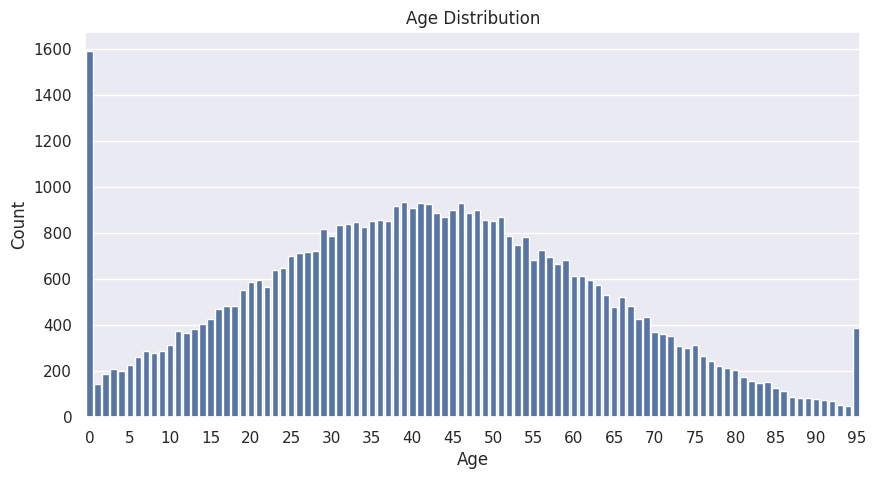

In [120]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x="age")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
for ind, label in enumerate(ax.get_xticklabels()):
    if not ind % 5 == 0:  # adjust to change frequency
        label.set_visible(False)

### Gender

Text(0, 0.5, 'Count')

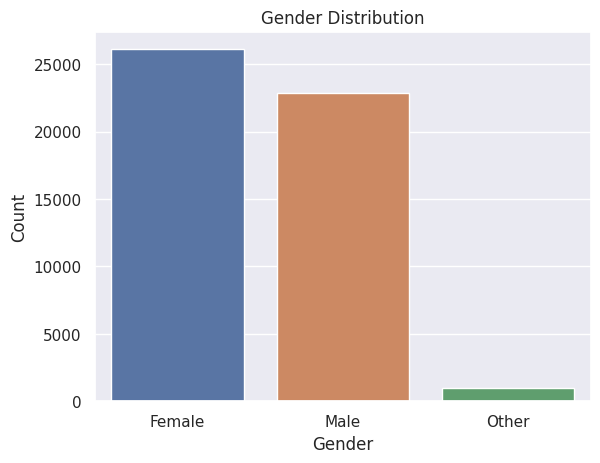

In [121]:
sns.countplot(data=df, x="gender", hue="gender")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

### Waiting Days

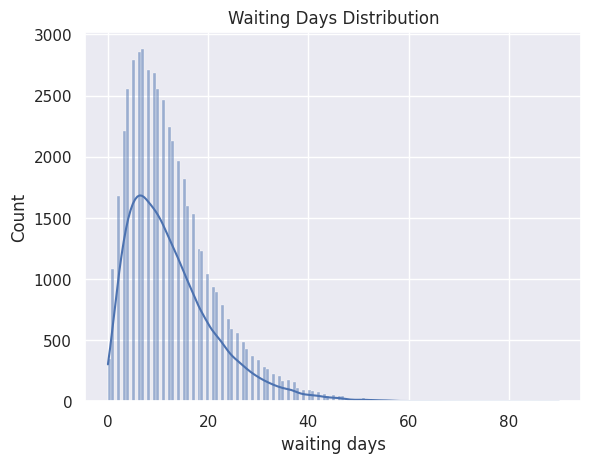

In [122]:
sns.histplot(data=df, x="waiting_days", kde=True)
plt.title("Waiting Days Distribution")
plt.xlabel("waiting days");

### No-show count

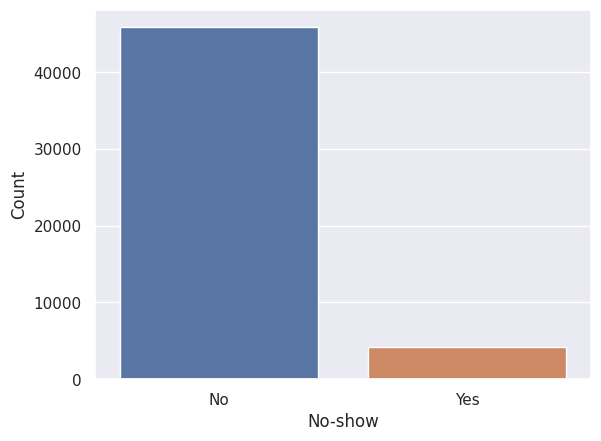

In [123]:
sns.countplot(data=df, x="no_show", hue="no_show")
plt.xticks(ticks=[0, 1], labels=["No", "Yes"])
plt.legend([],[], frameon=False) # hide the legend
plt.xlabel("No-show")
plt.ylabel("Count");

### Visual for the Blog

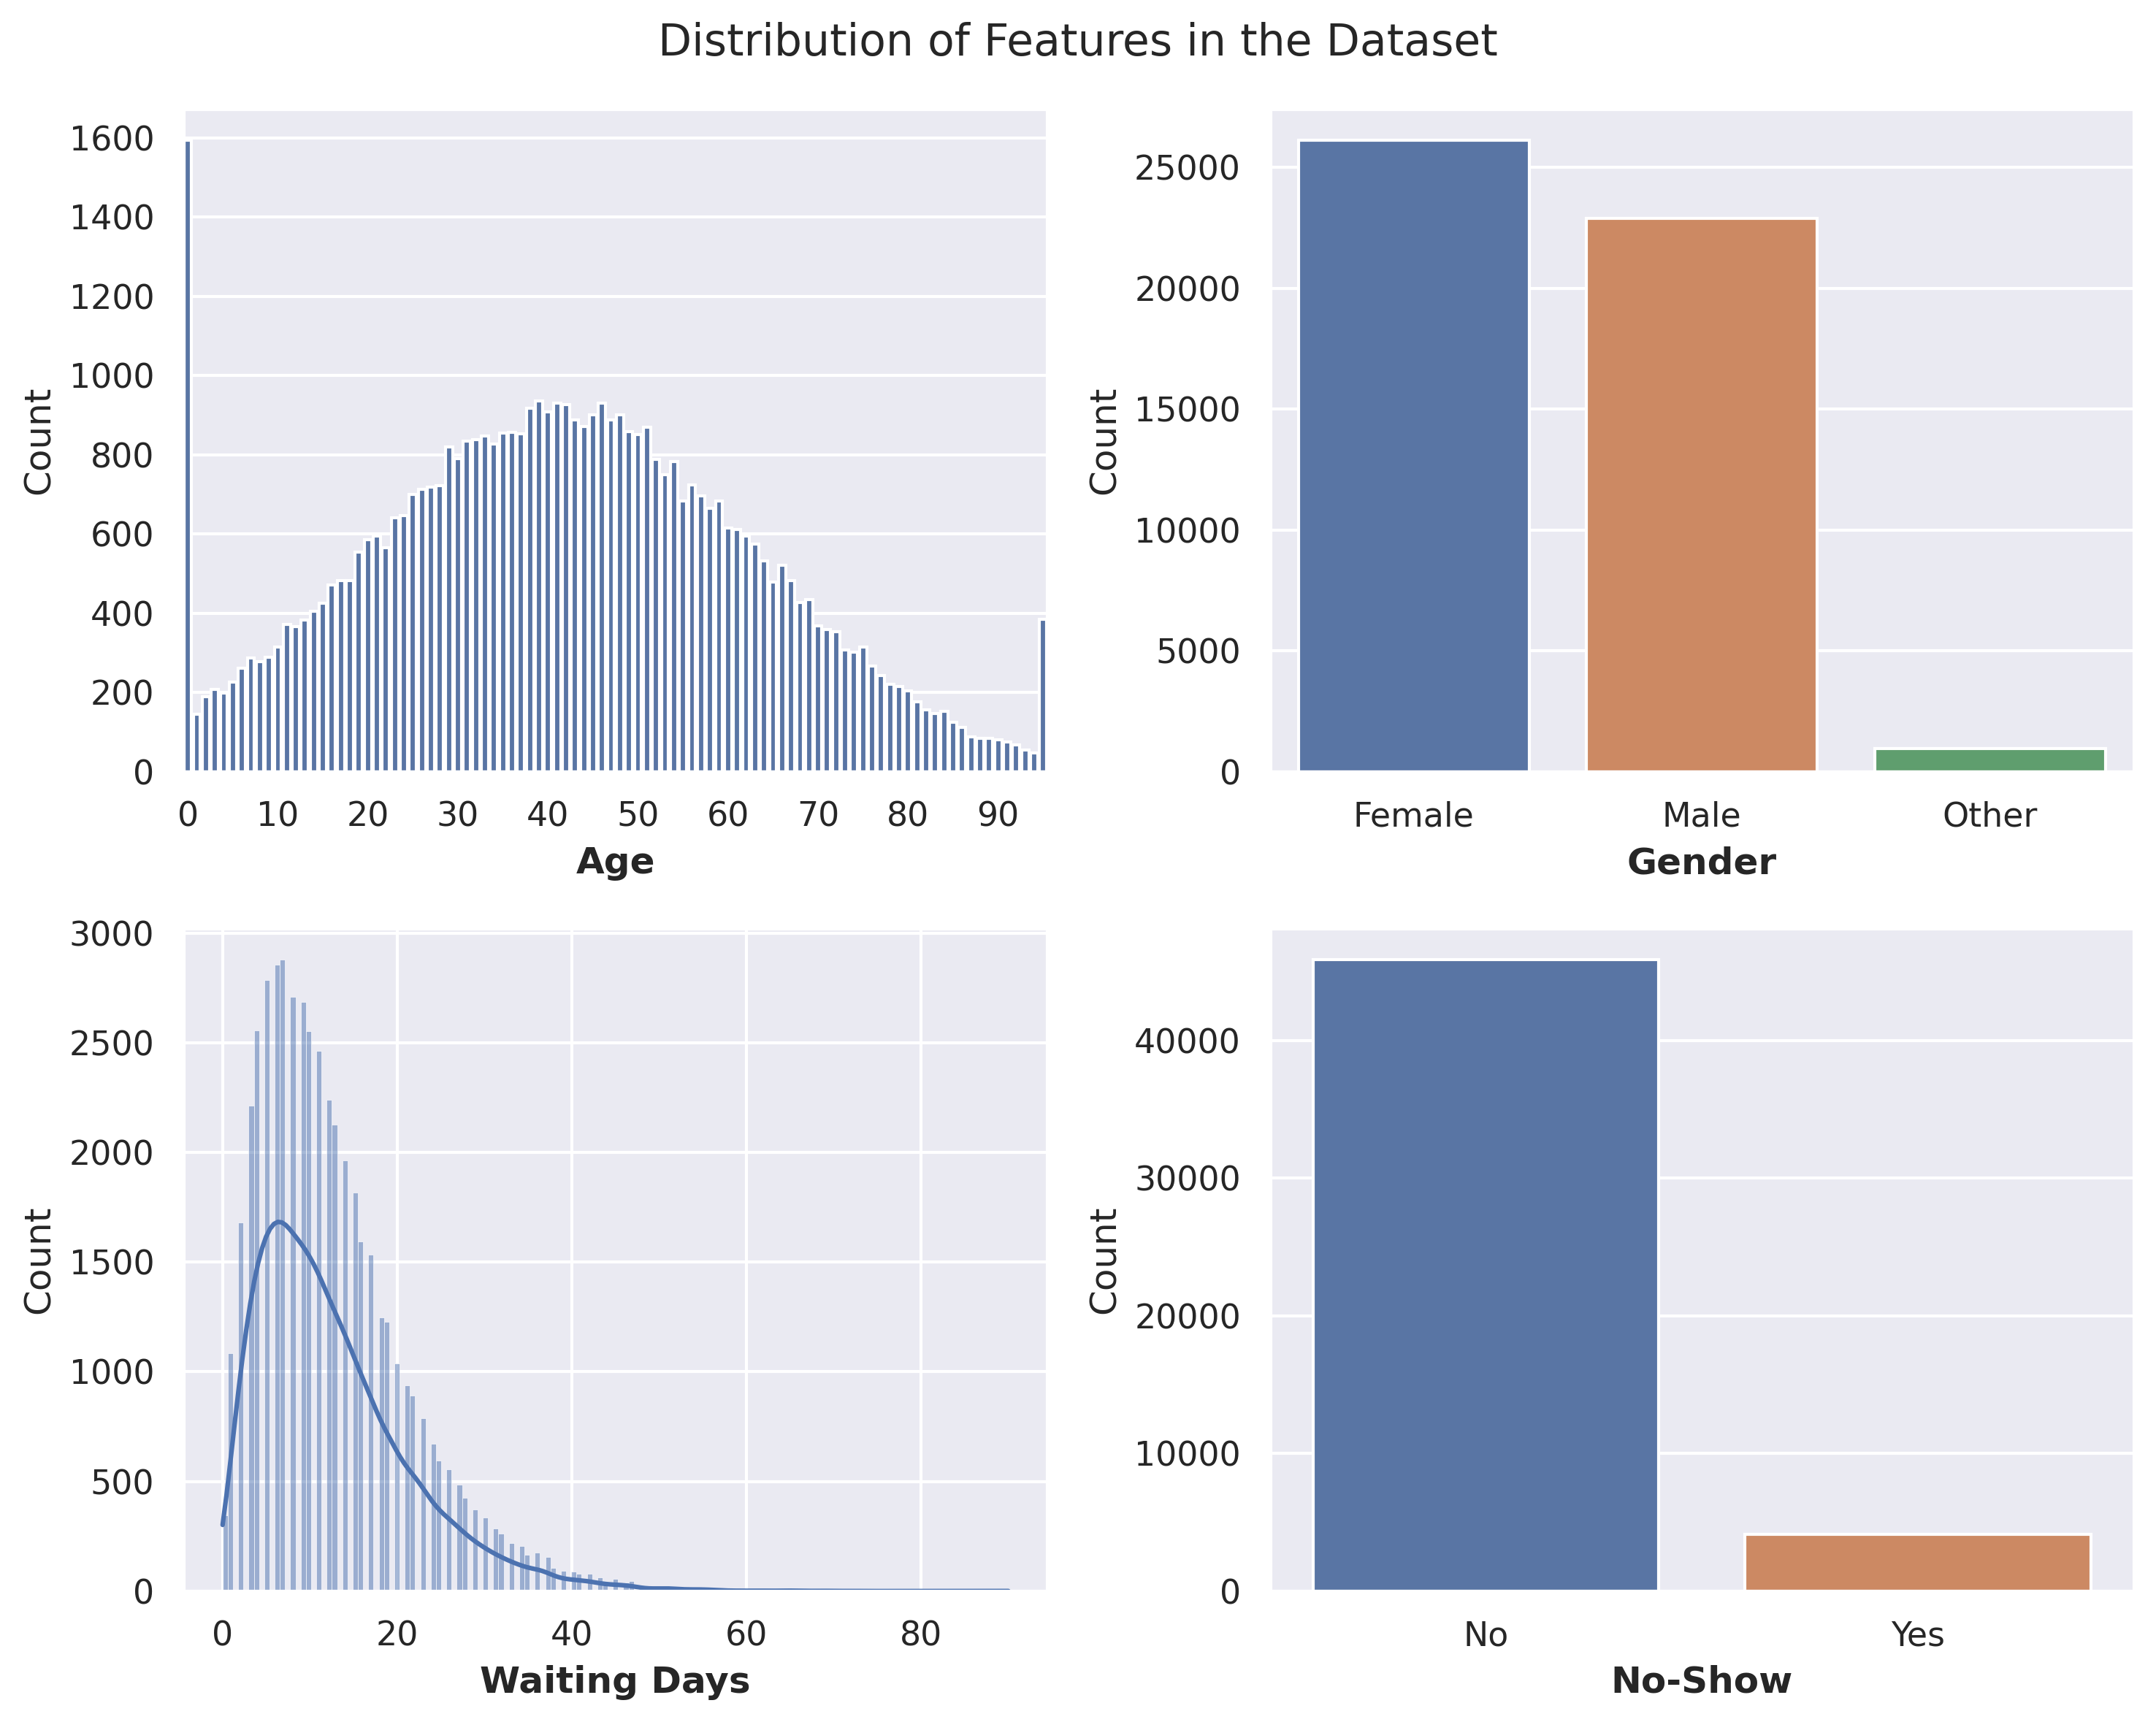

In [124]:
fig, axes = plt.subplots(2,2, figsize=(10,8), dpi=300)
plt.suptitle("Distribution of Features in the Dataset")

plt.sca(axes[0,0])
ax = sns.countplot(data=df, x="age")
plt.xlabel("Age", weight="semibold")
plt.ylabel("Count")
for ind, label in enumerate(ax.get_xticklabels()):
    if not ind % 10 == 0:  # adjust to change frequency
        label.set_visible(False)

plt.sca(axes[0,1])
sns.countplot(data=df, x="gender", hue="gender")
plt.xlabel("Gender", weight="semibold")
plt.ylabel("Count")

plt.sca(axes[1,0])
sns.histplot(data=df, x="waiting_days", kde=True)
plt.xlabel("Waiting Days", weight="semibold")

plt.sca(axes[1,1])
sns.countplot(data=df, x="no_show", hue="no_show")
plt.xticks(ticks=[0, 1], labels=["No", "Yes"])
plt.legend([],[], frameon=False) # hide the legend
plt.xlabel("No-Show", weight="semibold")
plt.ylabel("Count")

plt.tight_layout()
save_fig("distribution_of_features", resolution=300)

## No-show (target)

In [125]:
df["no_show"].value_counts()

no_show
0    45862
1     4138
Name: count, dtype: int64

### Correlation

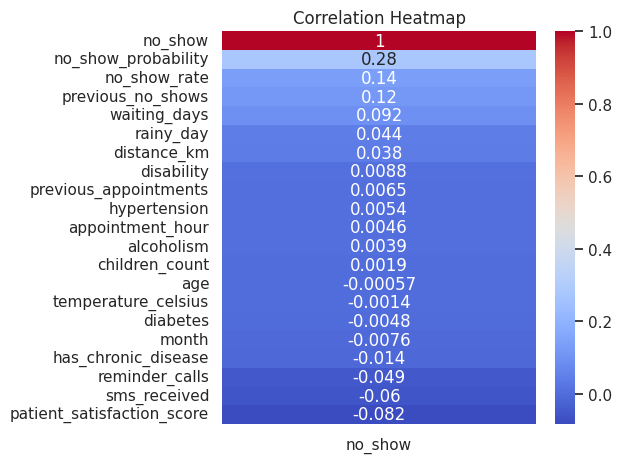

In [126]:
num = df.select_dtypes(np.number)
sns.heatmap(num.corr()[['no_show']].sort_values('no_show', ascending=False),
            annot=True, cmap='coolwarm');
plt.title("Correlation Heatmap");
save_fig("correlation_heatmap")

### waiting days

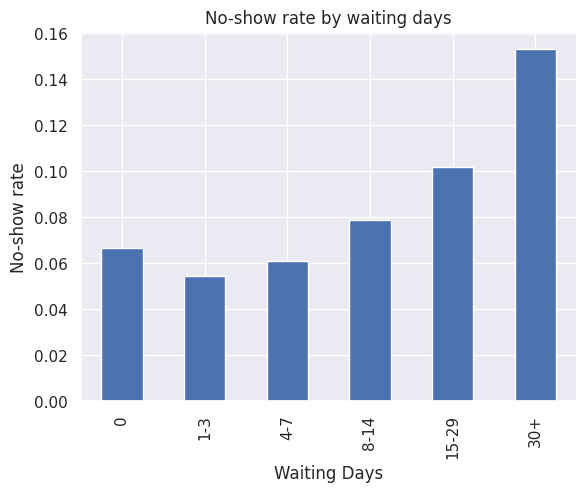

In [127]:
df['wait_bin'] = pd.cut(df['waiting_days'], bins=[-1 , 0, 3, 7, 14, 29, 1000],
                        labels=['0', '1-3','4-7','8-14','15-29', '30+'])
rate = df.groupby('wait_bin')['no_show'].mean()
rate.plot(kind='bar')
plt.title("No-show rate by waiting days")
plt.xlabel("Waiting Days")
plt.ylabel('No-show rate');

**Conclusion**: No-show rate rises with longer waiting period

### reminders (SMS/call)

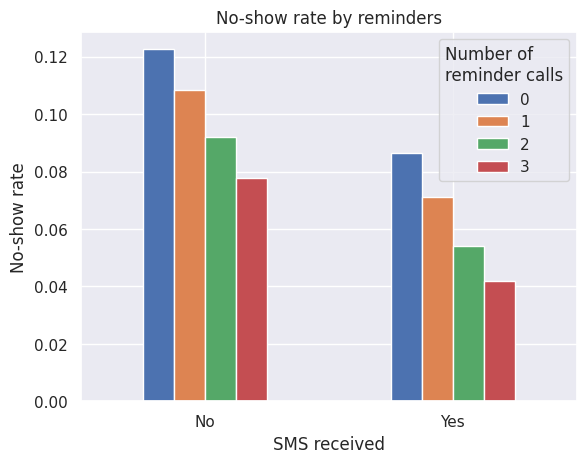

In [128]:
df.groupby(['sms_received','reminder_calls'])['no_show'].mean().unstack().plot(kind='bar')
plt.xlabel("SMS received")
plt.ylabel('No-show rate');
plt.title("No-show rate by reminders")
plt.legend(title="Number of\nreminder calls")
plt.xticks(ticks=[0, 1], labels=["No", "Yes"], rotation=0)
plt.show()

**Conclusion**: SMS reminders and call reminders both lower the no-show rate

### previous no-shows

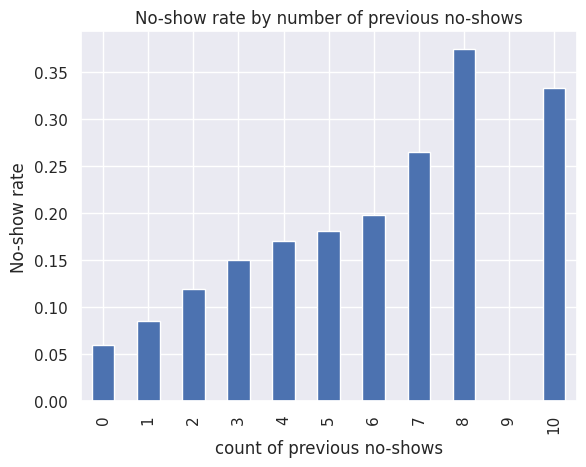

In [129]:
df.groupby("previous_no_shows")["no_show"].mean().plot(kind="bar")
plt.title("No-show rate by number of previous no-shows")
plt.xlabel("count of previous no-shows")
plt.ylabel("No-show rate");

**Conclusion**: The event of previous no-shows inceases the pobability of another no-show in the future

### patient satisfaction

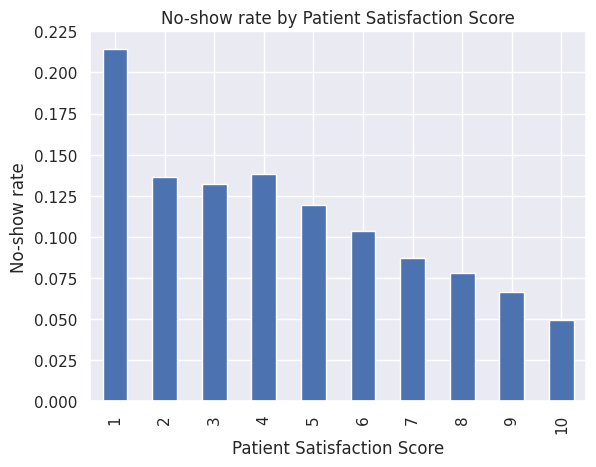

In [130]:
df['score_bin'] = pd.cut(df['patient_satisfaction_score'], bins=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                        labels=['1', '2', '3','4','5','6','7','8', '9', '10'])
df.groupby("score_bin")["no_show"].mean().plot(kind="bar")
plt.title("No-show rate by Patient Satisfaction Score")
plt.xlabel("Patient Satisfaction Score")
plt.ylabel("No-show rate")
plt.show()

**Conclusion**: The lower the patient satisfaction the higher to no-show rate

### Visual for the Blog

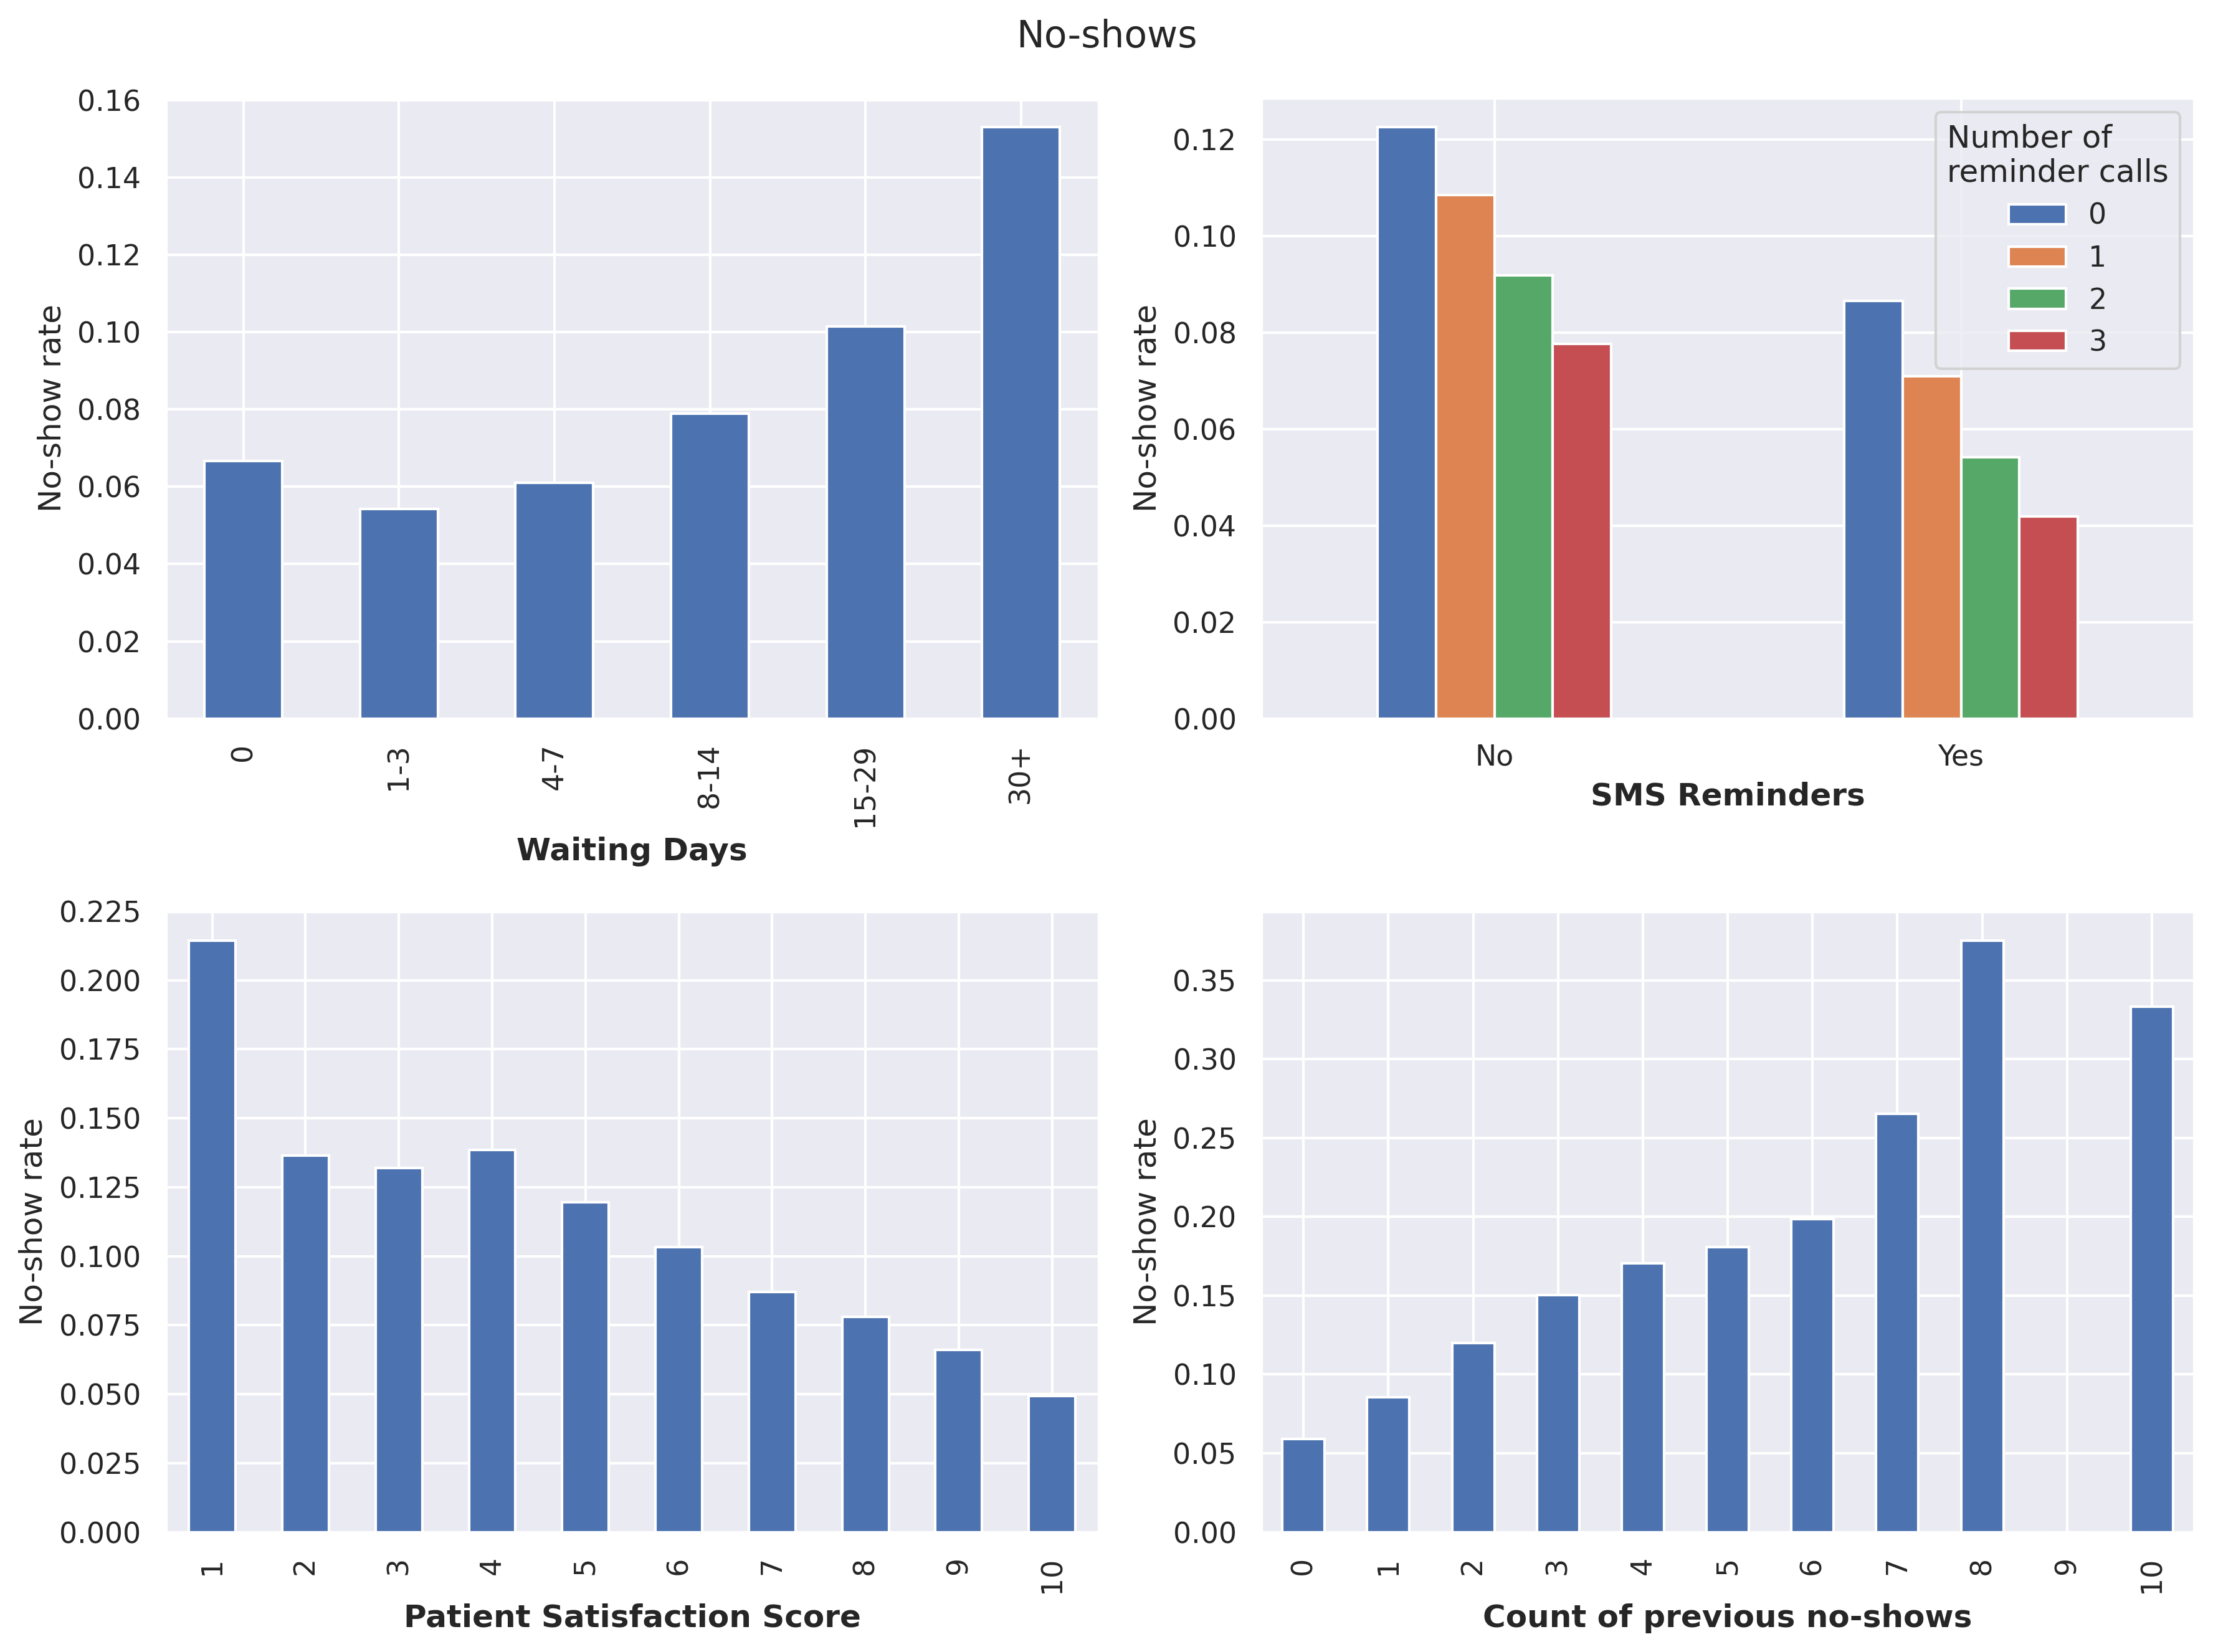

In [131]:
fig, axes = plt.subplots(2,2, figsize=(12,9), dpi=300)
plt.suptitle("No-shows")

plt.sca(axes[0,0])
rate.plot(kind='bar')
plt.xlabel("Waiting Days", weight="semibold")
plt.ylabel('No-show rate')

plt.sca(axes[0,1])
df.groupby(['sms_received','reminder_calls'])['no_show'].mean().unstack().plot(kind='bar', ax=axes[0, 1])
plt.xlabel("SMS Reminders", weight="semibold")
plt.ylabel('No-show rate')
plt.xticks(ticks=[0, 1], labels=["No", "Yes"], rotation=0)
plt.legend(title="Number of\nreminder calls")

plt.sca(axes[1,0])
df.groupby("score_bin")["no_show"].mean().plot(kind="bar")
plt.xlabel("Patient Satisfaction Score", weight="semibold")
plt.ylabel("No-show rate")

plt.sca(axes[1,1])
df.groupby("previous_no_shows")["no_show"].mean().plot(kind="bar")
plt.xlabel("Count of previous no-shows", weight="semibold")
plt.ylabel("No-show rate")

plt.tight_layout()
save_fig("no_shows")

# Preprocessing

In [204]:
# fresh read of the data
df = pd.read_csv("synthetic_healthcare_appointment_no_show.csv")

In [205]:
# dropping the target (no_show) & no_show_probability and useless columns (like patient_id)
drop_cloumns = ["no_show", "no_show_probability", "appointment_id", "patient_id", "scheduled_day", "appointment_day"]
X = df.drop(drop_cloumns, axis=1)
y = df["no_show"]

In [206]:
# splititng in a train and test set (40k vs 10k)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [207]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("OneHot", OneHotEncoder(drop="if_binary"))
])

In [208]:
preprocessing = ColumnTransformer([
    ("num", num_pipeline, X.select_dtypes(np.number).columns),
    ("cat", cat_pipeline, X.select_dtypes([object, str]).columns),
],
remainder="drop"
)

In [209]:
# pipeline for tree based models beacause the scaler can hurt them
num_pipeline_trees = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
    # no scaler
])
preprocessing_trees = ColumnTransformer([
    ("num", num_pipeline_trees, X.select_dtypes(np.number).columns),
    ("cat", cat_pipeline, X.select_dtypes([object, str]).columns),
],
remainder="drop"
)

# Training a Model

## Baseline models

**Looking for the most promising model before fine-tuning**

In [210]:
# Ensure exact class distribution representation across all 10 folds
cv_stratified = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [211]:
def evaluate_model(name, pipeline, X, y, cv=10):
    scores = cross_validate(pipeline, X, y, cv=cv_stratified,
                            scoring=["roc_auc", "f1", "recall", "precision"],
                            n_jobs=-1)
    return scores

### Dummy

In [212]:
dummy = make_pipeline(preprocessing, DummyClassifier(strategy="most_frequent"))

In [ ]:
dummy_results = evaluate_model("dummy", dummy, X_train, y_train)

-> Always predicts the most frequent class 

### Stochastic Gradient Descent

In [214]:
sgd_clf = make_pipeline(preprocessing, SGDClassifier(random_state=42, class_weight="balanced"))

In [215]:
sgd_results = evaluate_model("sgd", sgd_clf, X_train, y_train)

### Support Vector Machine

In [216]:
svm_clf = make_pipeline(preprocessing, LinearSVC(random_state=42, class_weight="balanced"))

In [217]:
svm_results = evaluate_model("svm", svm_clf, X_train, y_train)

### Decision Tree

In [218]:
decisionTree_clf = make_pipeline(preprocessing_trees, DecisionTreeClassifier(random_state=42, class_weight="balanced"))

In [219]:
dt_results = evaluate_model("decision_tree", decisionTree_clf, X_train, y_train)

### Random Forest

In [220]:
randomForest_clf = make_pipeline(preprocessing_trees, RandomForestClassifier(random_state=42, class_weight="balanced"))

In [ ]:
rf_results = evaluate_model("random_forest", randomForest_clf, X_train, y_train)

## Comparing Models

In [222]:
data = [dummy_results, sgd_results, svm_results, dt_results, rf_results]
labels = ["Dummy", "SGD", "SVM","DecisionTree", "RandomForest"]

In [223]:
results = []
for model, label in zip(data, labels):
    temp = {
        "Model": label,
        "test_roc_auc": model["test_roc_auc"].mean(),
        "test_precision": model["test_precision"].mean(),
        "test_recall": model["test_recall"].mean(),
        "test_f1": model["test_f1"].mean()
    }

    results.append(temp)

In [242]:
model_comparison = pd.DataFrame(results)
model_comparison.head().round(2) #.to_html()

,Model,test_roc_auc,test_precision,test_recall,test_f1
0,Dummy,0.50,0.00,0.00,0.00
1,SGD,0.67,0.14,0.62,0.22
2,SVM,0.71,0.15,0.63,0.24
3,DecisionTree,0.52,0.12,0.12,0.12
4,RandomForest,0.68,0.44,0.00,0.01


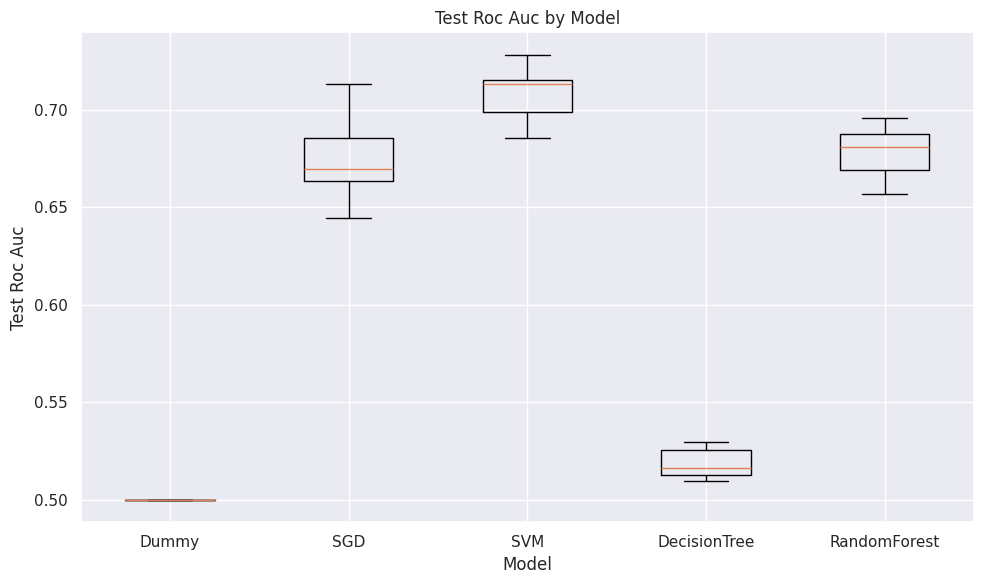

In [225]:
# Shows boxplots for a selected metric across models

# Choose metric to plot (options: "test_roc_auc", "test_precision", "test_recall", "test_f1")
metric_to_plot = "test_roc_auc"

plt.figure(figsize=(10,6))

# Extract the metric values for each model from 'data'
metric_data = [model[metric_to_plot] for model in data]

plt.boxplot(metric_data, tick_labels=labels)
plt.ylabel(metric_to_plot.replace("_", " ").title())
plt.xlabel("Model")
plt.title(f"{metric_to_plot.replace('_', ' ').title()} by Model")

save_fig(f"{metric_to_plot}_by_model")

## Fine-tuning

### LinearSVC

In [237]:
param_grid = {
    "linearsvc__C": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100] # range from very high regularization (0.001) to low regularization (100)
}

svm_tuned = make_pipeline(
    preprocessing,
    # loss="hinge" matches the default behavior of standard SVC
    # dual="auto" lets scikit-learn choose the fastest mathematical formulation based on your data shape
    LinearSVC(random_state=42, class_weight="balanced", loss="squared_hinge", dual="auto", max_iter=5000)
)

svm_grid_search = GridSearchCV(svm_tuned, param_grid=param_grid, cv=cv_stratified, scoring="roc_auc", n_jobs=-1)

In [238]:
svm_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'linearsvc__C': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of 

In [239]:
svm_grid_search.best_params_

{'linearsvc__C': 0.001}

In [240]:
svm_scores = evaluate_model("best_model", svm_grid_search.best_estimator_, X_train, y_train)

In [241]:
print("roc_auc: ",  svm_scores["test_roc_auc"].mean())
print("precision: ", svm_scores["test_precision"].mean())
print("recall: ", svm_scores["test_recall"].mean())
print("f1: ", svm_scores["test_f1"].mean())

roc_auc:  0.7099510144190033
precision:  0.14865184272205542
recall:  0.6262839879154078
f1:  0.24026621605987905


### SGD

In [231]:
param_dist = {
    "sgdclassifier__loss": ["log_loss", "modified_huber"],
    "sgdclassifier__penalty": ["l2", "l1", "elasticnet"],
    "sgdclassifier__alpha": loguniform(1e-5, 1e-1),   # continuous log-uniform
    "sgdclassifier__l1_ratio": uniform(0.1, 0.8),
    "sgdclassifier__max_iter": [500, 1000],
}

sgd_tuned = make_pipeline(
    preprocessing,
    SGDClassifier(random_state=42, class_weight="balanced")
)

sgd_random_search = RandomizedSearchCV(
    sgd_tuned,
    param_distributions=param_dist,
    cv=cv_stratified,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
)

In [ ]:
sgd_random_search.fit(X_train, y_train)

In [233]:
sgd_random_search.best_params_

{'sgdclassifier__alpha': np.float64(0.0024400607090817534),
 'sgdclassifier__l1_ratio': np.float64(0.4566662022828729),
 'sgdclassifier__loss': 'log_loss',
 'sgdclassifier__max_iter': 500,
 'sgdclassifier__penalty': 'elasticnet'}

In [234]:
sgd_scores = evaluate_model("best_model", sgd_random_search.best_estimator_, X_train, y_train)

In [235]:
print("roc_auc: ",  sgd_scores["test_roc_auc"].mean())
print("precision: ", sgd_scores["test_precision"].mean())
print("recall: ", sgd_scores["test_recall"].mean())
print("f1: ", sgd_scores["test_f1"].mean())

roc_auc:  0.7092298583955225
precision:  0.15133444087914674
recall:  0.6220543806646526
f1:  0.2432906321596507


# Performance Metrics

# Evaluating on the test set (final metrics)

              precision    recall  f1-score   support

        Show       0.95      0.70      0.80      9172
     No-show       0.15      0.59      0.24       828

    accuracy                           0.69     10000
   macro avg       0.55      0.64      0.52     10000
weighted avg       0.88      0.69      0.76     10000



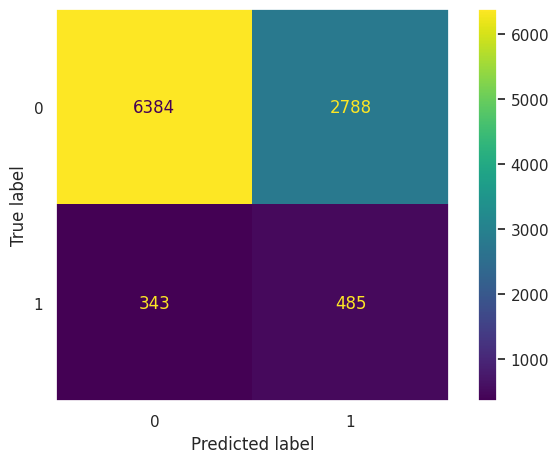

In [244]:
best_model = sgd_random_search.best_estimator_
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Show", "No-show"]))
cm = ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.grid(False)
save_fig("confusion_matrix")
plt.show()